In [1]:
%load_ext autoreload
%autoreload 2
!hostname
!pwd
import os, sys
print(sys.executable)
# os.environ['CUDA_VISIBLE_DEVICES'] = "7"
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "false"
# sys.path.append(os.path.abspath(".."))

slurm0-gpu1nodeset-0
/home/akarsh_sakana_ai/alife-repr/src
/home/akarsh_sakana_ai/.conda/envs/alife-repr-torch/bin/python


In [2]:
import os, sys, glob, pickle, copy, time
from functools import partial

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (15, 5)
import seaborn as sns
sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat
from einop import einop

import plotstyle
plotstyle.set_plot_style()

In [3]:
import torch
import torch.nn as nn

In [4]:
import torch
from torch import nn

from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# helpers

def pair(t):
    return t if isinstance(t, tuple) else (t, t)

# classes

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.norm = nn.LayerNorm(dim)

        self.attend = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        x = self.norm(x)

        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale

        attn = self.attend(dots)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout),
                FeedForward(dim, mlp_dim, dropout = dropout)
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x

        return self.norm(x)

class ViT(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim, pool = 'cls', channels = 3, dim_head = 64, dropout = 0., emb_dropout = 0.):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = channels * patch_height * patch_width
        assert pool in {'cls', 'mean'}, 'pool type must be either cls (cls token) or mean (mean pooling)'

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b (h p1) (w p2) c -> b (h w) (p1 p2 c)', p1 = patch_height, p2 = patch_width),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)

        self.pool = pool
        self.to_latent = nn.Identity()

        # self.mlp_head = nn.Linear(dim, num_classes)

        self.mlp_head = nn.Linear(dim, patch_height*patch_width*channels)
        self.patch_height, self.patch_width = patch_height, patch_width
        self.image_height, self.image_width = image_height, image_width

    def forward(self, img):
        x = self.to_patch_embedding(img)
        b, n, _ = x.shape

        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b = b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)

        x = self.transformer(x)

        # x = x.mean(dim = 1) if self.pool == 'mean' else x[:, 0]

        # x = self.to_latent(x)
        # return self.mlp_head(x)

        x = x[:, 1:, :]
        x = self.mlp_head(x)
        x = rearrange(x, "b (h w) (p1 p2 c) -> b (h p1) (w p2) c", p1 = self.patch_height, p2 = self.patch_width, h=self.image_height//self.patch_height)
        return x

In [5]:
from substrates.gol import GameOfLife
from rollout import rollout_simulation
from functools import partial

import jax
import jax.numpy as jnp
from jax.random import split


class Main:
    def __init__(self, grid_size=64, batch_size=32):
        self.substrate = GameOfLife(grid_size=grid_size)
        self.rollout_fn = partial(rollout_simulation, s0=None, substrate=self.substrate, fm=None, rollout_steps=65, time_sampling='video', img_size=None, return_state=True)
        self.batch_size = batch_size

    def generate_instance(self, rng):
        rng, _rng = split(rng)
        state = self.rollout_fn(_rng, 6152)['state']

        rng, _rng = split(rng)
        t0 = jax.random.randint(_rng, shape=(), minval=32, maxval=64)

        rng, _rng = split(rng)
        dt = 1
        t1 = t0 + dt
        x0, x1 = state[t0], state[t1]
        return dict(x=x0, y=x1, dt=dt, state=state, tx=t0, ty=t1)

    def generate_batch(self, rng):
        return jax.vmap(self.generate_instance)(split(rng, self.batch_size))

In [6]:
main = Main()

In [7]:
rng = jax.random.PRNGKey(0)
batch = main.generate_batch(rng)

In [8]:
batch.keys()

dict_keys(['dt', 'state', 'tx', 'ty', 'x', 'y'])

In [9]:
# vit = ViT(image_size=64, patch_size=4, num_classes=10, dim=64, depth=8, heads=8, mlp_dim=256, pool='cls', channels=2, dim_head=64, dropout=0., emb_dropout=0.)
vit = ViT(image_size=64, patch_size=4, num_classes=10, dim=512, depth=12, heads=8, mlp_dim=2048, pool='cls', channels=2, dim_head=64, dropout=0., emb_dropout=0.)
vit = vit.cuda()

opt = torch.optim.AdamW(vit.parameters(), lr=3e-4, weight_decay=0.0)


loss_history = []
pbar = tqdm(range(1000))
for i in pbar:
    rng = jax.random.PRNGKey(i)
    batch = main.generate_batch(rng)

    x, y = np.array(batch['x']), np.array(batch['y'])
    x, y = torch.from_numpy(x).cuda().long(), torch.from_numpy(y).cuda().long()
    x = torch.nn.functional.one_hot(x, num_classes=2).float()

    logits = vit(x)
    loss_ce = torch.nn.functional.cross_entropy(logits.reshape(-1, 2), y.reshape(-1), reduction='none')
    loss = loss_ce.mean()

    # print(x.shape, y.shape, logits.shape, x.dtype, y.dtype, logits.dtype)

    opt.zero_grad()
    loss.backward()
    opt.step()

    pbar.set_postfix(loss=loss.item())
    loss_history.append(loss.item())

  0%|          | 0/1000 [00:00<?, ?it/s]

In [10]:
loss_history = np.array(loss_history)

[]

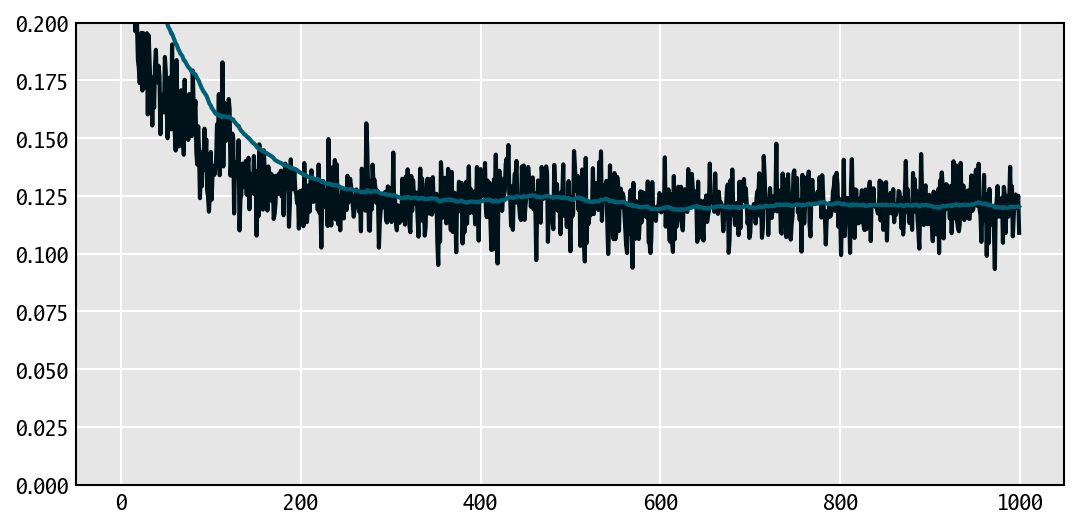

In [11]:
plt.plot(loss_history)
plt.plot(pd.DataFrame(loss_history).ewm(span=100).mean())
plt.ylim(0, 0.2)
plt.plot()

In [ ]:
grid_size, patch_size = 4, 1
main = Main(grid_size=grid_size, batch_size=128)
vit = ViT(image_size=grid_size, patch_size=patch_size, num_classes=10, dim=64, depth=8, heads=8, mlp_dim=256, pool='cls', channels=2, dim_head=16, dropout=0., emb_dropout=0.)
# vit = ViT(image_size=64, patch_size=4, num_classes=10, dim=512, depth=12, heads=8, mlp_dim=2048, pool='cls', channels=2, dim_head=64, dropout=0., emb_dropout=0.)
vit = vit.cuda()
n_params = sum(p.numel() for p in vit.parameters())
print(f"Number of parameters: {n_params}")
# vit = torch.compile(vit)

opt = torch.optim.AdamW(vit.parameters(), lr=3e-4, weight_decay=0.0)

loss_history = []
grad_norm_history = []
pbar = tqdm(range(1000))
for i in pbar:
    rng = jax.random.PRNGKey(i)
    batch = main.generate_batch(rng)

    x, y = np.array(batch['x']), np.array(batch['y'])
    x, y = torch.from_numpy(x).cuda().long(), torch.from_numpy(y).cuda().long()
    x = torch.nn.functional.one_hot(x, num_classes=2).float()

    logits = vit(x)
    loss_ce = torch.nn.functional.cross_entropy(logits.reshape(-1, 2), y.reshape(-1), reduction='none')
    loss = loss_ce.mean()

    # print(x.shape, y.shape, logits.shape, x.dtype, y.dtype, logits.dtype)
    opt.zero_grad()
    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(vit.parameters(), 1.0)
    opt.step()

    pbar.set_postfix(loss=loss.item(), perplexity=np.exp(loss.item()), grad_norm=grad_norm.item())
    loss_history.append(loss.item())
    grad_norm_history.append(grad_norm.item())

531142


  0%|          | 0/1000 [00:00<?, ?it/s]

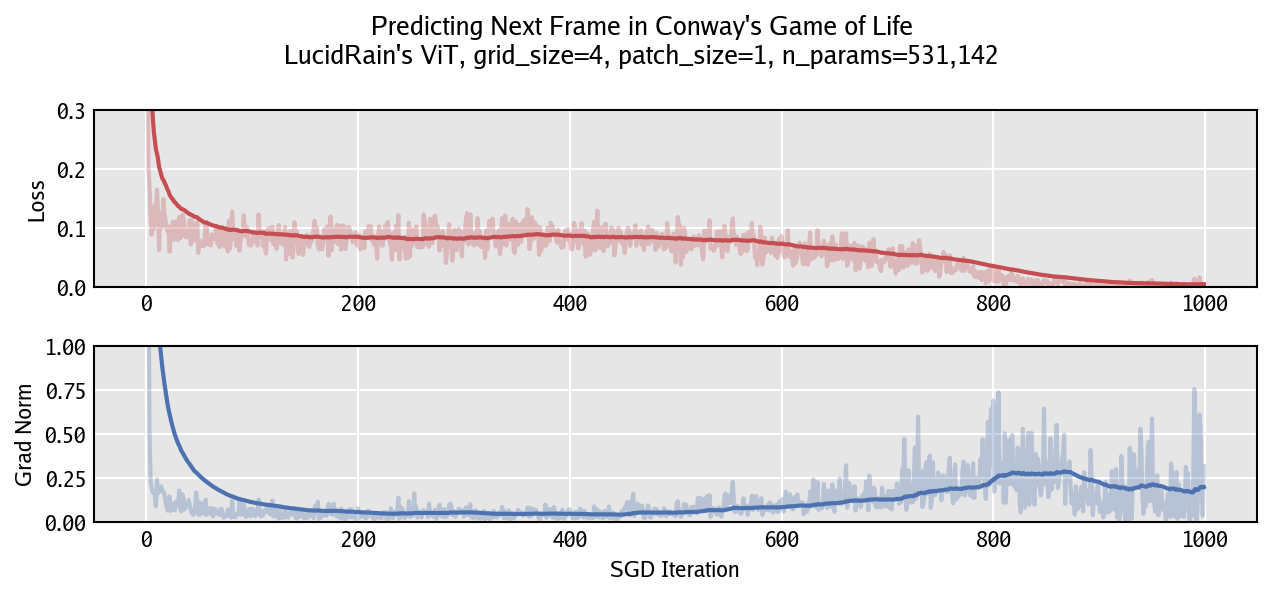

In [17]:
plt.subplot(211)
plt.plot(loss_history, c='r', alpha=0.3)
plt.plot(pd.DataFrame(loss_history).ewm(span=100).mean(), c='r', label='loss')
plt.ylabel("Loss")
plt.ylim(0, 0.3)
plt.subplot(212)
plt.plot(grad_norm_history, c='b', alpha=0.3)
plt.plot(pd.DataFrame(grad_norm_history).ewm(span=100).mean(), c='b', label='grad norm')
plt.ylabel("Grad Norm")
plt.ylim(0, 1.0)
plt.xlabel("SGD Iteration")
plt.suptitle(f"Predicting Next Frame in Conway's Game of Life\nLucidRain's ViT, grid_size={grid_size}, patch_size={patch_size}, n_params={n_params:,}")
plt.tight_layout()
plt.show()

In [8]:
grid_size, patch_size = 8, 1
main = Main(grid_size=grid_size, batch_size=128)
vit = ViT(image_size=grid_size, patch_size=patch_size, num_classes=10, dim=64, depth=8, heads=8, mlp_dim=256, pool='cls', channels=2, dim_head=16, dropout=0., emb_dropout=0.)
# vit = ViT(image_size=64, patch_size=4, num_classes=10, dim=512, depth=12, heads=8, mlp_dim=2048, pool='cls', channels=2, dim_head=64, dropout=0., emb_dropout=0.)
vit = vit.cuda()
n_params = sum(p.numel() for p in vit.parameters())
print(f"Number of parameters: {n_params}")
# vit = torch.compile(vit)

opt = torch.optim.AdamW(vit.parameters(), lr=3e-4, weight_decay=0.0)

loss_history = []
grad_norm_history = []
pbar = tqdm(range(1000))
for i in pbar:
    rng = jax.random.PRNGKey(i)
    batch = main.generate_batch(rng)

    x, y = np.array(batch['x']), np.array(batch['y'])
    x, y = torch.from_numpy(x).cuda().long(), torch.from_numpy(y).cuda().long()
    x = torch.nn.functional.one_hot(x, num_classes=2).float()

    logits = vit(x)
    loss_ce = torch.nn.functional.cross_entropy(logits.reshape(-1, 2), y.reshape(-1), reduction='none')
    loss = loss_ce.mean()

    # print(x.shape, y.shape, logits.shape, x.dtype, y.dtype, logits.dtype)
    opt.zero_grad()
    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(vit.parameters(), 1.0)
    opt.step()

    pbar.set_postfix(loss=loss.item(), perplexity=np.exp(loss.item()), grad_norm=grad_norm.item())
    loss_history.append(loss.item())
    grad_norm_history.append(grad_norm.item())

Number of parameters: 534214


  0%|          | 0/1000 [00:00<?, ?it/s]

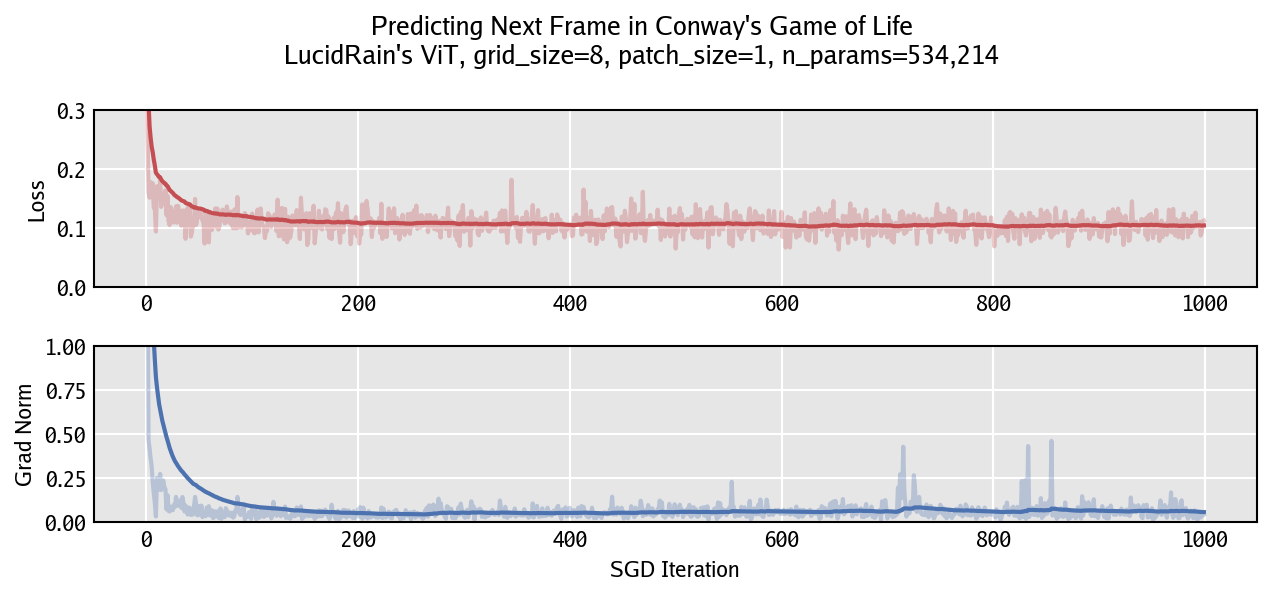

In [9]:
plt.subplot(211)
plt.plot(loss_history, c='r', alpha=0.3)
plt.plot(pd.DataFrame(loss_history).ewm(span=100).mean(), c='r', label='loss')
plt.ylabel("Loss")
plt.ylim(0, 0.3)
plt.subplot(212)
plt.plot(grad_norm_history, c='b', alpha=0.3)
plt.plot(pd.DataFrame(grad_norm_history).ewm(span=100).mean(), c='b', label='grad norm')
plt.ylabel("Grad Norm")
plt.ylim(0, 1.0)
plt.xlabel("SGD Iteration")
plt.suptitle(f"Predicting Next Frame in Conway's Game of Life\nLucidRain's ViT, grid_size={grid_size}, patch_size={patch_size}, n_params={n_params:,}")
plt.tight_layout()
plt.show()

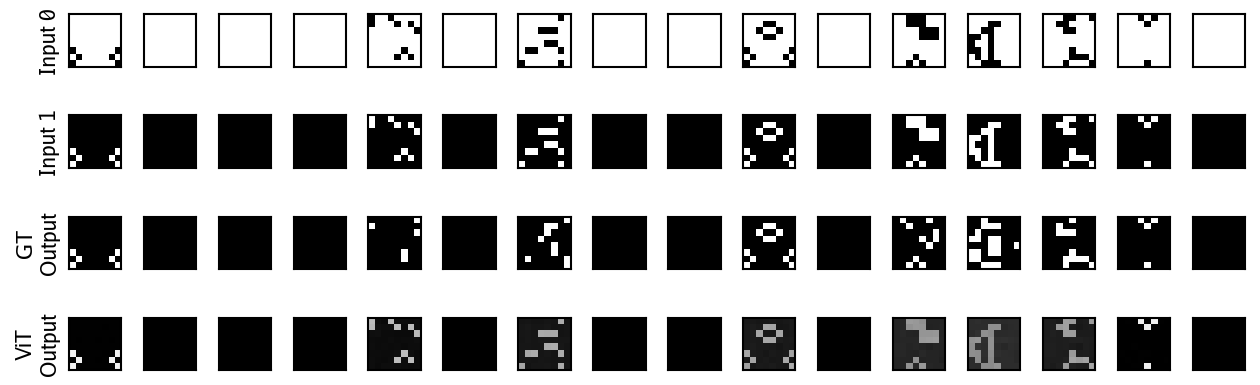

In [34]:
probs = torch.softmax(logits, dim=-1).detach()

plt.figure(figsize=(8.5, 3))
for i in range(16):
    plt.subplot(4, 16, i+1)
    plt.imshow(x[i, :, :, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1); plt.xticks([]); plt.yticks([])
    if i == 0:
        plt.ylabel("Input 0")
    plt.subplot(4, 16, i+1+16)
    plt.imshow(x[i, :, :, 1].cpu().numpy(), cmap='gray', vmin=0, vmax=1); plt.xticks([]); plt.yticks([])
    if i == 0:
        plt.ylabel("Input 1")
    plt.subplot(4, 16, i+1+16*2)
    plt.imshow(y[i, :, :].cpu().numpy(), cmap='gray', vmin=0, vmax=1); plt.xticks([]); plt.yticks([])
    if i == 0:
        plt.ylabel("GT\nOutput")
    plt.subplot(4, 16, i+1+16*3)
    plt.imshow(probs[i, :, :, 1].cpu().numpy(), cmap='gray', vmin=0, vmax=1); plt.xticks([]); plt.yticks([])
    if i == 0:
        plt.ylabel("ViT\nOutput")
plt.tight_layout()
plt.show()

In [8]:
# grid_size, patch_size = 12, 3
grid_size, patch_size = 8, 1
main = Main(grid_size=grid_size, batch_size=256)
vit = ViT(image_size=grid_size, patch_size=patch_size, num_classes=10, dim=64, depth=12, heads=8, mlp_dim=256, pool='cls', channels=2, dim_head=16, dropout=0., emb_dropout=0.)
# vit = ViT(image_size=64, patch_size=4, num_classes=10, dim=512, depth=12, heads=8, mlp_dim=2048, pool='cls', channels=2, dim_head=64, dropout=0., emb_dropout=0.)
vit = vit.cuda()
n_params = sum(p.numel() for p in vit.parameters())
print(f"Number of parameters: {n_params}")
# vit = torch.compile(vit)

opt = torch.optim.AdamW(vit.parameters(), lr=3e-4, weight_decay=0.0)

loss_history = []
grad_norm_history = []
pbar = tqdm(range(100000))
for i in pbar:
    rng = jax.random.PRNGKey(i)
    batch = main.generate_batch(rng)

    x, y = np.array(batch['x']), np.array(batch['y'])
    x, y = torch.from_numpy(x).cuda().long(), torch.from_numpy(y).cuda().long()
    x = torch.nn.functional.one_hot(x, num_classes=2).float()

    logits = vit(x)
    loss_ce = torch.nn.functional.cross_entropy(logits.reshape(-1, 2), y.reshape(-1), reduction='none')
    loss = loss_ce.mean()

    # print(x.shape, y.shape, logits.shape, x.dtype, y.dtype, logits.dtype)
    opt.zero_grad()
    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(vit.parameters(), 1.0)
    opt.step()

    pbar.set_postfix(loss=loss.item(), perplexity=np.exp(loss.item()), grad_norm=grad_norm.item())
    loss_history.append(loss.item())
    grad_norm_history.append(grad_norm.item())

Number of parameters: 798918


  0%|          | 0/100000 [00:00<?, ?it/s]

: 